<div style="background: white;
            padding: 30px 35px;
            border-radius: 8px;
            border-left: 6px solid #e94560;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;">

<h1 style="margin-bottom: 5px;">NB02: Risk Modelling — Value at Risk & Expected Shortfall</h1>

<p style="font-weight: bold; margin-top: 0;">Personal Project · Portfolio Risk Dashboard · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 12th April 2026</li>
    <li>🎯 <strong>Purpose:</strong> Quantify the downside risk of a 5-asset portfolio using three VaR methodologies and Expected Shortfall</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li><code>../data/raw/prices.csv</code> — cleaned daily adjusted closing prices from NB01</li>
    <li><code>../data/processed/returns.csv</code> — daily log returns from NB01</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/processed/portfolio_returns.csv</code> — weighted daily portfolio returns</li>
    <li><code>../figures/var_comparison.png</code> — VaR comparison across methods</li>
    <li><code>../figures/historical_var.png</code> — historical return distribution with VaR marked</li>
    <li><code>../figures/monte_carlo.png</code> — Monte Carlo simulation paths</li>
    <li><code>../figures/drawdown.png</code> — portfolio drawdown chart</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Portfolio return construction using weighted asset returns</li>
    <li>Historical VaR — empirical percentile method</li>
    <li>Parametric VaR — normal distribution assumption</li>
    <li>Monte Carlo VaR — simulated return paths</li>
    <li>Expected Shortfall (CVaR) — average loss beyond VaR</li>
    <li>Drawdown analysis — peak-to-trough loss visualisation</li>
</ul>

<p><strong>Workflow:</strong> Load Data → Build Portfolio → Historical VaR → Parametric VaR → Monte Carlo VaR → Expected Shortfall → Drawdown → Compare & Reflect</p>

</div>

## ⚙️ Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data from NB01

### 📍 Load Prices & Returns

In [2]:
prices  = pd.read_csv("../data/raw/prices.csv", index_col="Date", parse_dates=True)
returns = pd.read_csv("../data/processed/returns.csv", index_col="Date", parse_dates=True)

print(f"✅ Data loaded")
print(f"📐 Prices shape  : {prices.shape}")
print(f"📐 Returns shape : {returns.shape}")
print(f"📅 Period        : {returns.index[0].date()} → {returns.index[-1].date()}")
returns.head()

✅ Data loaded
📐 Prices shape  : (2513, 5)
📐 Returns shape : (2512, 5)
📅 Period        : 2016-01-05 → 2025-12-30


,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2016-01-05,0.002233,0.002815,-0.001737,0.001690,-0.004042
2016-01-06,-0.019306,0.014337,-0.009652,-0.012695,0.013386
2016-01-07,-0.031350,0.014041,-0.031814,-0.024284,0.001793
2016-01-08,-0.010786,-0.004438,-0.008234,-0.011038,0.004468
2016-01-11,-0.000339,-0.008935,0.003072,0.000989,-0.011003


## 💼 Section 2: Build Portfolio Returns

### 📍 Construct Weighted Portfolio Returns

A portfolio return on any given day is simply the weighted average of each asset's return
that day. For example, if SPY is up 1% and makes up 35% of the portfolio, it contributes
0.35% to the overall portfolio return. We sum this across all five assets to get a single
daily return series for the whole portfolio.

In [3]:
WEIGHTS = np.array([0.35, 0.25, 0.15, 0.15, 0.10])  # SPY, TLT, GLD, QQQ, EEM

# Weighted sum of daily returns
portfolio_returns = returns.dot(WEIGHTS)
portfolio_returns.name = "Portfolio"

print(f"✅ Portfolio returns constructed")
print(f"📐 Shape         : {portfolio_returns.shape}")
print(f"📈 Mean daily return  : {portfolio_returns.mean():.4f} ({portfolio_returns.mean()*252:.2f} annualised)")
print(f"📉 Std daily return   : {portfolio_returns.std():.4f} ({portfolio_returns.std()*np.sqrt(252):.4f} annualised)")
print(f"⬇️  Worst single day  : {portfolio_returns.min():.4f} ({portfolio_returns.min()*100:.2f}%)")
print(f"⬆️  Best single day   : {portfolio_returns.max():.4f} ({portfolio_returns.max()*100:.2f}%)")

✅ Portfolio returns constructed
📐 Shape         : (2512,)
📈 Mean daily return  : 0.0004 (0.11 annualised)
📉 Std daily return   : 0.0084 (0.1328 annualised)
⬇️  Worst single day  : -0.0798 (-7.98%)
⬆️  Best single day   : 0.0651 (6.51%)


## 📐 Section 3: Historical VaR

### 📍 Step 1: Calculate Historical VaR

Historical VaR is the simplest and most intuitive method. We take the actual observed
return distribution and find the percentile that corresponds to our confidence level.
At 95% confidence, we are asking: "What loss did we exceed on only 5% of trading days?"
No assumptions about the shape of the distribution — we let the data speak for itself.
This is its biggest strength: it naturally captures fat tails and real crisis behaviour.
Its weakness is that it can only reflect risks that already occurred in the sample period.

In [4]:
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]

historical_var = {}
for cl in CONFIDENCE_LEVELS:
    var = np.percentile(portfolio_returns, (1 - cl) * 100)
    historical_var[cl] = var
    print(f"  Historical VaR ({int(cl*100)}%) : {var:.4f}  →  on 1 in {int(1/(1-cl))} days, "
          f"portfolio loses more than {abs(var)*100:.2f}%")

  Historical VaR (90%) : -0.0089  →  on 1 in 10 days, portfolio loses more than 0.89%
  Historical VaR (95%) : -0.0128  →  on 1 in 19 days, portfolio loses more than 1.28%
  Historical VaR (99%) : -0.0215  →  on 1 in 99 days, portfolio loses more than 2.15%


### 📍 Step 2: Visualise Historical VaR

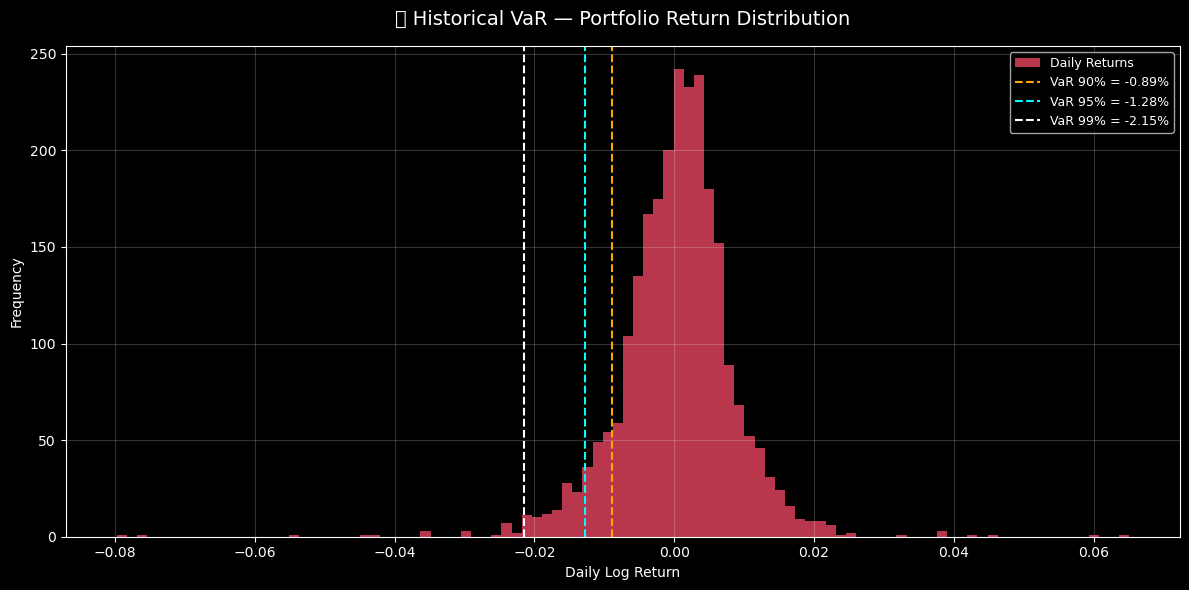

💾 Saved to ../figures/historical_var.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(portfolio_returns, bins=100, color="#e94560", edgecolor="none", alpha=0.8, label="Daily Returns")

colors = ["orange", "cyan", "white"]
for (cl, var), color in zip(historical_var.items(), colors):
    ax.axvline(var, color=color, linestyle="--", linewidth=1.5,
               label=f"VaR {int(cl*100)}% = {var*100:.2f}%")

ax.set_title("📐 Historical VaR — Portfolio Return Distribution", fontsize=14, pad=15)
ax.set_xlabel("Daily Log Return")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/historical_var.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/historical_var.png")

## 📊 Section 4: Parametric VaR

### 📍 Calculate Parametric VaR

Parametric VaR assumes returns follow a normal distribution. We estimate the mean and
standard deviation of portfolio returns, then use the properties of the normal distribution
to calculate the loss at a given confidence level. The formula is:

**VaR = μ - z × σ**

Where μ is the mean daily return, σ is the standard deviation, and z is the z-score
corresponding to the confidence level (e.g. 1.645 for 95%, 2.326 for 99%).

The advantage is simplicity and speed — no need for large historical datasets. The major
weakness, which NB01's return distributions already flagged, is that real returns have
fat tails. The normal distribution underestimates the probability of extreme losses,
so parametric VaR will likely give a less conservative estimate than historical VaR.

In [6]:
mu    = portfolio_returns.mean()
sigma = portfolio_returns.std()

z_scores = {0.90: 1.282, 0.95: 1.645, 0.99: 2.326}

parametric_var = {}
for cl in CONFIDENCE_LEVELS:
    var = mu - z_scores[cl] * sigma
    parametric_var[cl] = var
    print(f"  Parametric VaR ({int(cl*100)}%) : {var:.4f}  →  {abs(var)*100:.2f}% loss threshold")

print(f"\n  μ (mean daily return) : {mu:.6f}")
print(f"  σ (daily volatility)  : {sigma:.6f}")

  Parametric VaR (90%) : -0.0103  →  1.03% loss threshold
  Parametric VaR (95%) : -0.0133  →  1.33% loss threshold
  Parametric VaR (99%) : -0.0190  →  1.90% loss threshold

  μ (mean daily return) : 0.000433
  σ (daily volatility)  : 0.008368


## 🎲 Section 5: Monte Carlo VaR

### 📍 Step 1: Run Monte Carlo Simulation

Monte Carlo VaR simulates thousands of possible future return paths by drawing random
returns from a normal distribution calibrated to our portfolio's historical mean and
standard deviation. We then look at the distribution of simulated outcomes to estimate VaR.

The intuition is: instead of relying only on what actually happened (historical VaR),
we generate a huge number of hypothetical scenarios and ask what the worst outcomes
look like across all of them. With 10,000 simulations we get a smooth, stable estimate
even in the tails. Like parametric VaR it assumes normality, but it is more flexible —
in more advanced versions you can simulate from non-normal distributions to better
capture fat tails.

In [7]:
np.random.seed(42)
N_SIMULATIONS = 10_000
N_DAYS        = 1  # 1-day VaR

simulated_returns = np.random.normal(mu, sigma, N_SIMULATIONS)

monte_carlo_var = {}
for cl in CONFIDENCE_LEVELS:
    var = np.percentile(simulated_returns, (1 - cl) * 100)
    monte_carlo_var[cl] = var
    print(f"  Monte Carlo VaR ({int(cl*100)}%) : {var:.4f}  →  {abs(var)*100:.2f}% loss threshold")

  Monte Carlo VaR (90%) : -0.0104  →  1.04% loss threshold
  Monte Carlo VaR (95%) : -0.0134  →  1.34% loss threshold
  Monte Carlo VaR (99%) : -0.0190  →  1.90% loss threshold


### 📍 Step 2: Visualise Monte Carlo Simulation Paths

Here we simulate 50 possible 30-day portfolio return paths to visualise the range of
outcomes the portfolio could experience over the next month. Each line is one possible
future — the spread of lines shows the uncertainty in future returns.

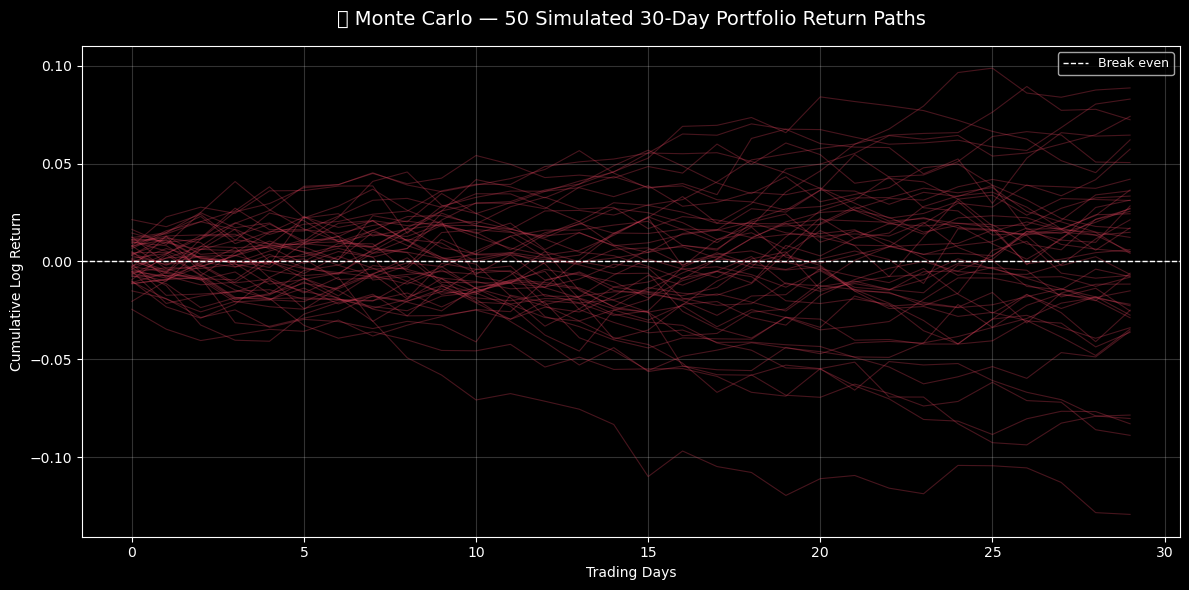

💾 Saved to ../figures/monte_carlo.png


In [8]:
N_PATHS = 50
N_DAYS_PATH = 30

fig, ax = plt.subplots(figsize=(12, 6))

for _ in range(N_PATHS):
    path = np.cumsum(np.random.normal(mu, sigma, N_DAYS_PATH))
    ax.plot(path, color="#e94560", alpha=0.3, linewidth=0.8)

ax.axhline(0, color="white", linestyle="--", linewidth=1, label="Break even")
ax.set_title("🎲 Monte Carlo — 50 Simulated 30-Day Portfolio Return Paths", fontsize=14, pad=15)
ax.set_xlabel("Trading Days")
ax.set_ylabel("Cumulative Log Return")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/monte_carlo.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/monte_carlo.png")

## ⚠️ Section 6: Expected Shortfall (CVaR)

### 📍 Calculate Expected Shortfall

Expected Shortfall (ES), also called Conditional VaR (CVaR), answers a question VaR
deliberately ignores: *given that we have breached the VaR threshold, how bad does it
actually get on average?*

VaR only tells you the threshold — it says nothing about the severity of losses beyond
it. ES fills this gap by averaging all the losses that fall in the tail beyond VaR.
For example, if 95% VaR is -1.5%, ES asks: on those worst 5% of days, what was the
average loss? This makes ES a more complete risk measure and is now preferred by
regulators under the Basel IV framework over VaR for this reason.

In [9]:
expected_shortfall = {}
for cl in CONFIDENCE_LEVELS:
    threshold = historical_var[cl]
    tail_losses = portfolio_returns[portfolio_returns <= threshold]
    es = tail_losses.mean()
    expected_shortfall[cl] = es
    print(f"  ES ({int(cl*100)}%) : {es:.4f}  →  on the worst {int((1-cl)*100)}% of days, "
          f"average loss was {abs(es)*100:.2f}%")
    print(f"           (VaR was {abs(threshold)*100:.2f}% — ES is {abs(es/threshold):.2f}x worse)\n")

  ES (90%) : -0.0150  →  on the worst 9% of days, average loss was 1.50%
           (VaR was 0.89% — ES is 1.69x worse)

  ES (95%) : -0.0194  →  on the worst 5% of days, average loss was 1.94%
           (VaR was 1.28% — ES is 1.52x worse)

  ES (99%) : -0.0323  →  on the worst 1% of days, average loss was 3.23%
           (VaR was 2.15% — ES is 1.50x worse)



## 📉 Section 7: Drawdown Analysis

### 📍 Calculate & Visualise Drawdowns

A drawdown measures how far the portfolio has fallen from its previous peak at any point
in time. It answers the question an investor actually cares about: "If I had invested at
the worst possible time, how much would I have lost before recovering?"

VaR and ES measure single-day risk. Drawdown captures sustained, multi-day losses —
the kind that actually test investor patience and force panic selling. A portfolio might
have a modest daily VaR but a brutal maximum drawdown if losses accumulate over weeks.

In [10]:
# Cumulative portfolio value starting at 1
cumulative = (1 + portfolio_returns).cumprod()

# Running maximum (peak so far)
running_max = cumulative.cummax()

# Drawdown = how far below the peak we are
drawdown = (cumulative - running_max) / running_max

max_drawdown = drawdown.min()
max_drawdown_date = drawdown.idxmin()

print(f"📉 Maximum Drawdown     : {max_drawdown*100:.2f}%")
print(f"📅 Occurred on          : {max_drawdown_date.date()}")
print(f"⬇️  Meaning the portfolio fell {abs(max_drawdown)*100:.2f}% from its prior peak on this date")

📉 Maximum Drawdown     : -27.43%
📅 Occurred on          : 2022-10-14
⬇️  Meaning the portfolio fell 27.43% from its prior peak on this date


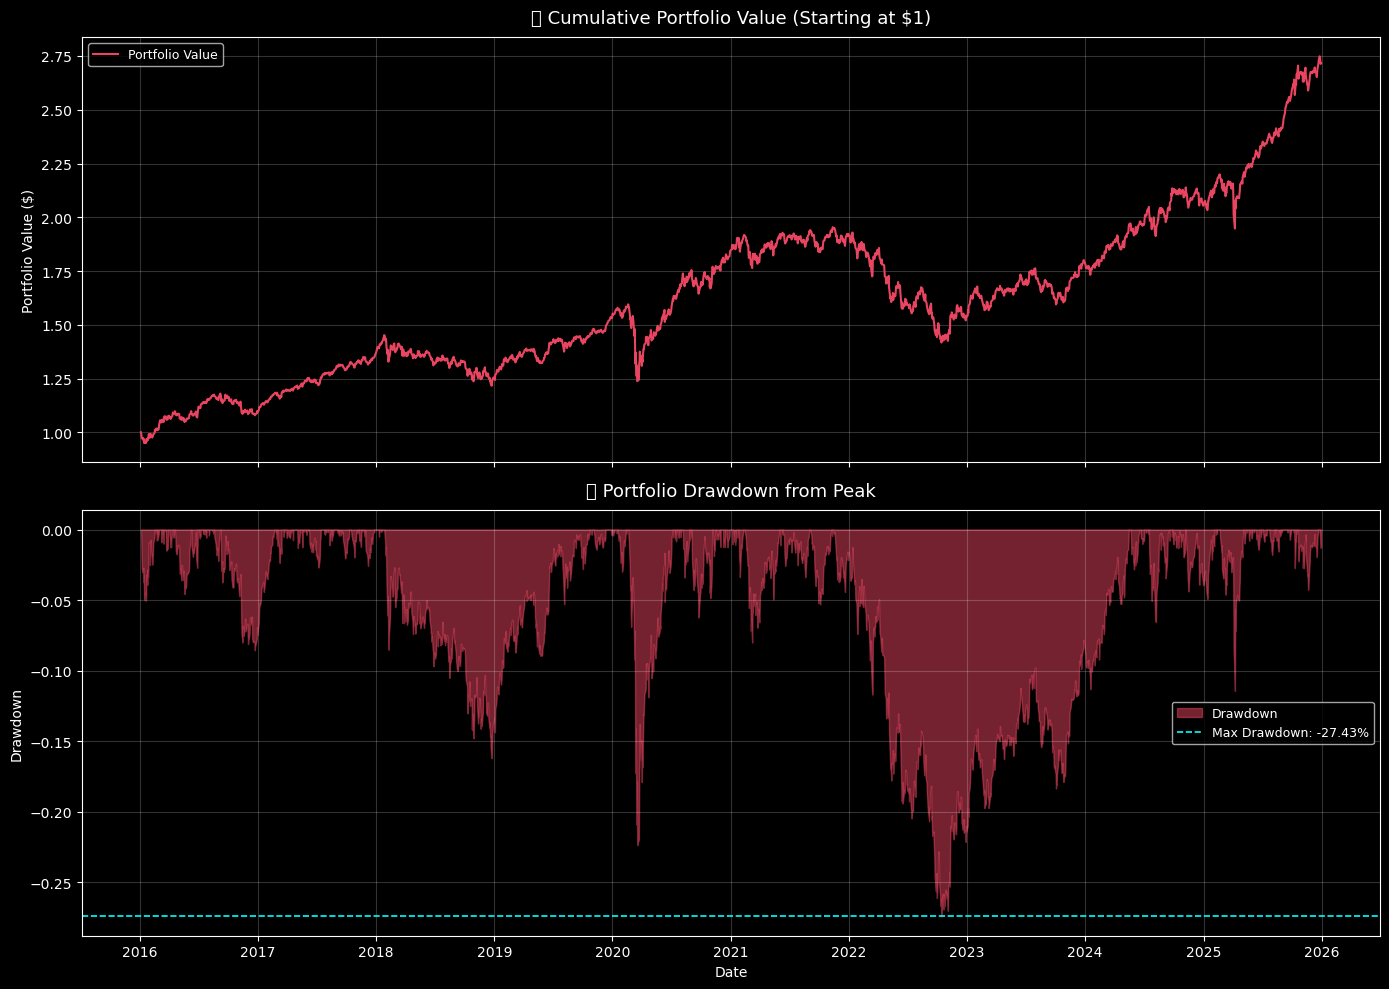

💾 Saved to ../figures/drawdown.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top — cumulative portfolio value
axes[0].plot(cumulative, color="#e94560", linewidth=1.5, label="Portfolio Value")
axes[0].set_title("📈 Cumulative Portfolio Value (Starting at $1)", fontsize=13, pad=10)
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Bottom — drawdown
axes[1].fill_between(drawdown.index, drawdown, 0, color="#e94560", alpha=0.5, label="Drawdown")
axes[1].axhline(max_drawdown, color="cyan", linestyle="--", linewidth=1.2,
                label=f"Max Drawdown: {max_drawdown*100:.2f}%")
axes[1].set_title("📉 Portfolio Drawdown from Peak", fontsize=13, pad=10)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../figures/drawdown.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/drawdown.png")

## 📊 Section 8: VaR Comparison Summary

### 📍 Compare All Three Methods

In [12]:
summary = pd.DataFrame({
    "Historical VaR"  : {cl: f"{abs(v)*100:.3f}%" for cl, v in historical_var.items()},
    "Parametric VaR"  : {cl: f"{abs(v)*100:.3f}%" for cl, v in parametric_var.items()},
    "Monte Carlo VaR" : {cl: f"{abs(v)*100:.3f}%" for cl, v in monte_carlo_var.items()},
    "Expected Shortfall": {cl: f"{abs(v)*100:.3f}%" for cl, v in expected_shortfall.items()}
})
summary.index = ["90%", "95%", "99%"]
summary.index.name = "Confidence Level"

print("📊 VaR & ES Comparison Summary")
print("="*65)
print(summary.to_string())

📊 VaR & ES Comparison Summary
                 Historical VaR Parametric VaR Monte Carlo VaR Expected Shortfall
Confidence Level                                                                 
90%                      0.886%         1.029%          1.038%             1.502%
95%                      1.279%         1.333%          1.341%             1.940%
99%                      2.150%         1.903%          1.899%             3.228%


### 📍 Visualise VaR Comparison

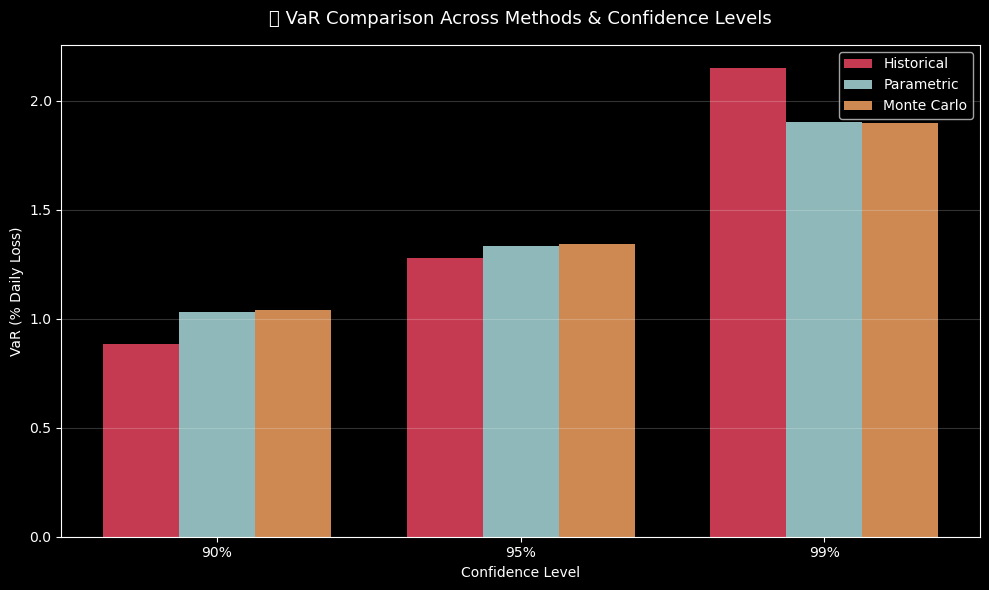

💾 Saved to ../figures/var_comparison.png


In [13]:
labels = ["90%", "95%", "99%"]
x = np.arange(len(labels))
width = 0.25

hist_vals  = [abs(historical_var[cl])*100  for cl in CONFIDENCE_LEVELS]
param_vals = [abs(parametric_var[cl])*100  for cl in CONFIDENCE_LEVELS]
mc_vals    = [abs(monte_carlo_var[cl])*100 for cl in CONFIDENCE_LEVELS]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, hist_vals,  width, label="Historical",   color="#e94560", alpha=0.85)
ax.bar(x,         param_vals, width, label="Parametric",   color="#a8dadc", alpha=0.85)
ax.bar(x + width, mc_vals,    width, label="Monte Carlo",  color="#f4a261", alpha=0.85)

ax.set_title("📊 VaR Comparison Across Methods & Confidence Levels", fontsize=13, pad=15)
ax.set_xlabel("Confidence Level")
ax.set_ylabel("VaR (% Daily Loss)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=10)
ax.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../figures/var_comparison.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/var_comparison.png")

## 💾 Section 9: Save Portfolio Returns

In [14]:
portfolio_returns.to_csv("../data/processed/portfolio_returns.csv")

print("✅ Files saved:")
print("   📄 ../data/processed/portfolio_returns.csv")
print("\n🚀 Ready for NB03 — Streamlit Dashboard")

✅ Files saved:
   📄 ../data/processed/portfolio_returns.csv

🚀 Ready for NB03 — Streamlit Dashboard


## 🪞 Personal Reflection Notes — NB02

**🎯 Key Decisions Made in This Notebook**

The central decision in this notebook was which VaR methods to implement and in what
order. I started with historical VaR because it requires no distributional assumptions —
it simply reads off the empirical percentile from actual observed returns. This made it
the natural baseline. Parametric VaR came second as the textbook approach, and Monte
Carlo third as a simulation-based bridge between the two.

The choice of confidence levels (90%, 95%, 99%) was deliberate. 95% is the industry
standard for internal risk management. 99% is used under Basel regulatory requirements
for bank capital calculations. Including 90% gave a lower bound for comparison. Using all
three together shows how risk estimates escalate as you demand more certainty about
protecting against tail events.

For Expected Shortfall I used the historical tail losses rather than the parametric
formula. This was intentional — since we already established that returns have fat tails,
using the actual observed losses in the tail gives a more honest picture of what happens
in the worst scenarios rather than assuming a smooth normal tail.

---

**📊 What the Results Revealed**

The portfolio's basic statistics were a reasonable starting point. The mean daily return
of 0.04% (0.11 annualised) reflects the modest but positive drift of a diversified
multi-asset portfolio over the 2016–2025 period. The daily volatility of 0.84%
(13.28% annualised) is lower than a pure equity portfolio would produce — which is
exactly the point of including TLT and GLD as diversifiers. The worst single day of
-7.98% and best of +6.51% confirm the fat tails we identified in NB01.

The historical VaR results tell a clear story. At 95% confidence, the portfolio lost
more than 1.28% on 1 in every 20 trading days — roughly once a month. At 99%
confidence, losses exceeded 2.15% on 1 in every 99 days — roughly two to three times
per year. These are not rare catastrophic events; they are the normal rhythm of risk
that a portfolio manager has to budget for every single year.

The most important finding was the comparison between historical and parametric VaR at
the 99% confidence level. Historical VaR gave 2.15%, while parametric VaR gave only
1.90% — parametric underestimated tail risk by roughly 13% compared to what actually
happened in the data. This confirmed exactly what the fat tails in NB01's return
distributions suggested: the normal distribution assigns too low a probability to
extreme losses. At 90% and 95% the gap was smaller (0.886% vs 1.029%, and 1.279% vs
1.333% respectively), which makes sense — the fat tail effect becomes more pronounced
the deeper into the tail you go. Interestingly, at 90% historical VaR was actually
lower than parametric, suggesting the normal distribution slightly overstates risk in
the moderate range but significantly understates it in the extreme tail.

Monte Carlo VaR came in almost identical to parametric VaR across all confidence levels
(1.038% vs 1.029% at 90%, 1.341% vs 1.333% at 95%, 1.899% vs 1.903% at 99%). This
was expected — both methods are grounded in the normal distribution assumption, so they
should converge to the same answer. The near-perfect agreement between the two is
actually a useful sanity check: it confirms the simulation is working correctly and that
10,000 simulations was sufficient for stable convergence. The Monte Carlo paths chart
reinforced this — the fan of 50 simulated 30-day paths spreads out symmetrically around
zero, with most paths staying within a ±5% range and a small number of paths diverging
to around ±10% by day 30. The symmetry of the fan reflects the normal distribution
assumption, and in a more advanced version I could simulate from a fat-tailed
distribution to produce a more asymmetric, realistic fan.

Expected Shortfall told the most sobering story. At 95% confidence, ES was 1.94%
compared to a VaR of 1.28% — meaning that on the worst 5% of days, the average loss
was 1.52 times worse than the VaR threshold alone would suggest. At 99% confidence,
ES jumped to 3.23% against a VaR of 2.15% — 1.50 times worse. This gap between VaR
and ES is where the real danger lives. A risk manager who only monitors VaR knows the
door to the danger zone but has no idea how far the drop is on the other side. ES
answers that question, which is why Basel IV regulators replaced VaR with ES as the
primary capital requirement metric.

The drawdown analysis grounded all of this in reality. The maximum drawdown of -27.43%
occurred on 14 October 2022 — deep into the rate hike cycle that we identified in NB01
as the most aggressive in 40 years. Looking at the drawdown chart, two major troughs
are visible: a sharp but brief drawdown during the COVID crash of early 2020, from
which the portfolio recovered relatively quickly, and then a deeper, more prolonged
trough running through 2022 as rate hikes simultaneously crushed both the equity and
bond portions of the portfolio. The 2022 drawdown was worse precisely because the
usual hedge broke down — TLT, which normally cushions equity losses, was itself falling
sharply. This is the real-world consequence of the weak TLT-equity correlation we
observed in NB01's correlation matrix.

What the drawdown chart makes viscerally clear is the difference between a single-day
risk measure like VaR and the sustained multi-week losses an investor actually
experiences. The daily 99% VaR of 2.15% sounds manageable in isolation. But the
drawdown chart shows that losses compounded over months until the portfolio was sitting
27.43% below its prior peak — the kind of sustained pain that tests investor patience
and historically triggers panic selling at the worst possible time.

---

**🔜 What This Sets Up for NB03**

NB03 will bring everything built here into an interactive Streamlit dashboard, allowing
the user to adjust portfolio weights and confidence levels dynamically and see how risk
estimates change in real time. The key tension to carry forward is the gap between
historical and parametric VaR at high confidence levels — this should be surfaced
clearly in the dashboard as it is the most practically important finding of this
notebook. The maximum drawdown of -27.43% in October 2022 is also worth highlighting
prominently in the dashboard, as it connects the abstract risk numbers to a real
historical event with a clear economic explanation.